# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
import joblib

In [3]:
import os
print("Current Working Directory:", os.getcwd())

# If the file is not found, you can verify files in the directory
print("Files in current directory:", os.listdir())

Current Working Directory: /content
Files in current directory: ['.config', 'credit_risk.xls', 'sample_data']


### Loading Data

In [4]:
df=pd.read_excel("credit_risk.xls")

# EDA

In [5]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [6]:
# Rename mapping
rename_dict = {
    'Unnamed: 0': 'ID',
    'X1': 'LIMIT_BAL',
    'X2': 'GENDER',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6',
    'Y': 'DEFAULT_NEXT_MONTH'
}

# Apply rename
df = df.rename(columns=rename_dict)

# Check
print(df.head())


   ID  LIMIT_BAL GENDER  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0  ID  LIMIT_BAL    SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4   
1   1      20000      2          2         1   24      2      2     -1     -1   
2   2     120000      2          2         2   26     -1      2      0      0   
3   3      90000      2          2         2   34      0      0      0      0   
4   4      50000      2          2         1   37      0      0      0      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3   
1  ...          0          0          0         0       689         0   
2  ...       3272       3455       3261         0      1000      1000   
3  ...      14331      14948      15549      1518      1500      1000   
4  ...      28314      28959      29547      2000      2019      1200   

   PAY_AMT4  PAY_AMT5  PAY_AMT6          DEFAULT_NEXT_MONTH  
0  PAY_AMT4 

In [7]:
df = df.iloc[1:].reset_index(drop=True)

In [8]:
df.head()

,ID,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


| **Variable Name**    | **Description**                                                                                                  |
| -------------------- | ---------------------------------------------------------------------------------------------------------------- |
| `ID`                 | Unique identifier for each credit card client.                                                                   |
| `LIMIT_BAL`          | Amount of credit granted (in Dollars). This includes both individual and supplementary credit.        |
| `SEX`                | Gender of the client (1 = Male, 2 = Female).                                                                     |
| `EDUCATION`          | Education level of the client:<br>- 1 = Graduate School<br>- 2 = University<br>- 3 = High School<br>- 4 = Others |
| `MARRIAGE`           | Marital status:<br>- 1 = Married<br>- 2 = Single<br>- 3 = Others                                                 |
| `AGE`                | Age of the client in years.                                                                                      |
| `PAY_0`              | Repayment status in September 2005: how late payments were (negative = paid on time).                            |
| `PAY_2`              | Repayment status in August 2005 (same scale).                                                                    |
| `PAY_3`              | Repayment status in July 2005.                                                                                   |
| `PAY_4`              | Repayment status in June 2005.                                                                                   |
| `PAY_5`              | Repayment status in May 2005.                                                                                    |
| `PAY_6`              | Repayment status in April 2005.                                                                                  |
| `BILL_AMT1`          | Amount of bill statement in September 2005 (NT dollar).                                                          |
| `BILL_AMT2`          | Amount of bill statement in August 2005.                                                                         |
| `BILL_AMT3`          | Amount of bill statement in July 2005.                                                                           |
| `BILL_AMT4`          | Amount of bill statement in June 2005.                                                                           |
| `BILL_AMT5`          | Amount of bill statement in May 2005.                                                                            |
| `BILL_AMT6`          | Amount of bill statement in April 2005.                                                                          |
| `PAY_AMT1`           | Amount paid in September 2005 (NT dollar).                                                                       |
| `PAY_AMT2`           | Amount paid in August 2005.                                                                                      |
| `PAY_AMT3`           | Amount paid in July 2005.                                                                                        |
| `PAY_AMT4`           | Amount paid in June 2005.                                                                                        |
| `PAY_AMT5`           | Amount paid in May 2005.                                                                                         |
| `PAY_AMT6`           | Amount paid in April 2005.                                                                                       |
| `DEFAULT_NEXT_MONTH` | Target variable indicating whether the client defaulted on payment next month (0 = No, 1 = Yes).                 |


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  30000 non-null  object
 1   LIMIT_BAL           30000 non-null  object
 2   GENDER              30000 non-null  object
 3   EDUCATION           30000 non-null  object
 4   MARRIAGE            30000 non-null  object
 5   AGE                 30000 non-null  object
 6   PAY_0               30000 non-null  object
 7   PAY_2               30000 non-null  object
 8   PAY_3               30000 non-null  object
 9   PAY_4               30000 non-null  object
 10  PAY_5               30000 non-null  object
 11  PAY_6               30000 non-null  object
 12  BILL_AMT1           30000 non-null  object
 13  BILL_AMT2           30000 non-null  object
 14  BILL_AMT3           30000 non-null  object
 15  BILL_AMT4           30000 non-null  object
 16  BILL_AMT5           30

In [10]:
# Convert appropriate columns to numeric
num_cols = [
    'LIMIT_BAL', 'AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

df.drop(columns="ID")

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [11]:
df.describe()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [12]:
df.shape

(30000, 25)

In [13]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
GENDER,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


I structured EDA by credit risk dimensions: borrower demographics, exposure, repayment behavior, billing patterns, and payment capacity, rather than analyzing features individually

## Target Variable Analysis - Default Behaviour

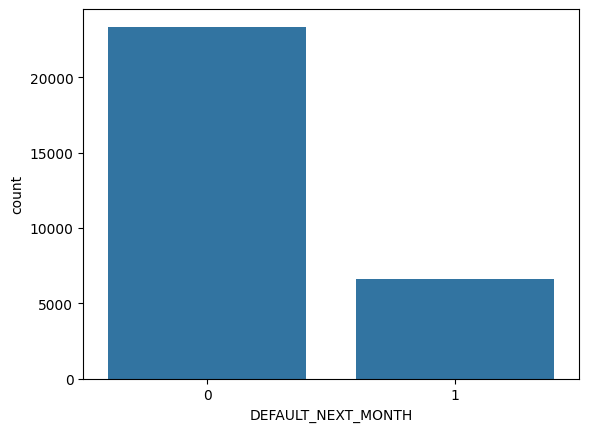

In [14]:
sns.countplot(data=df, x="DEFAULT_NEXT_MONTH")
plt.show()

In [15]:
default_count = df['DEFAULT_NEXT_MONTH'].value_counts().get(1, 0)
total_count = len(df)
default_percentage = (default_count / total_count) * 100

print(f"Default Percentage: {default_percentage:.2f}%")

Default Percentage: 22.12%


## Customer Demographics

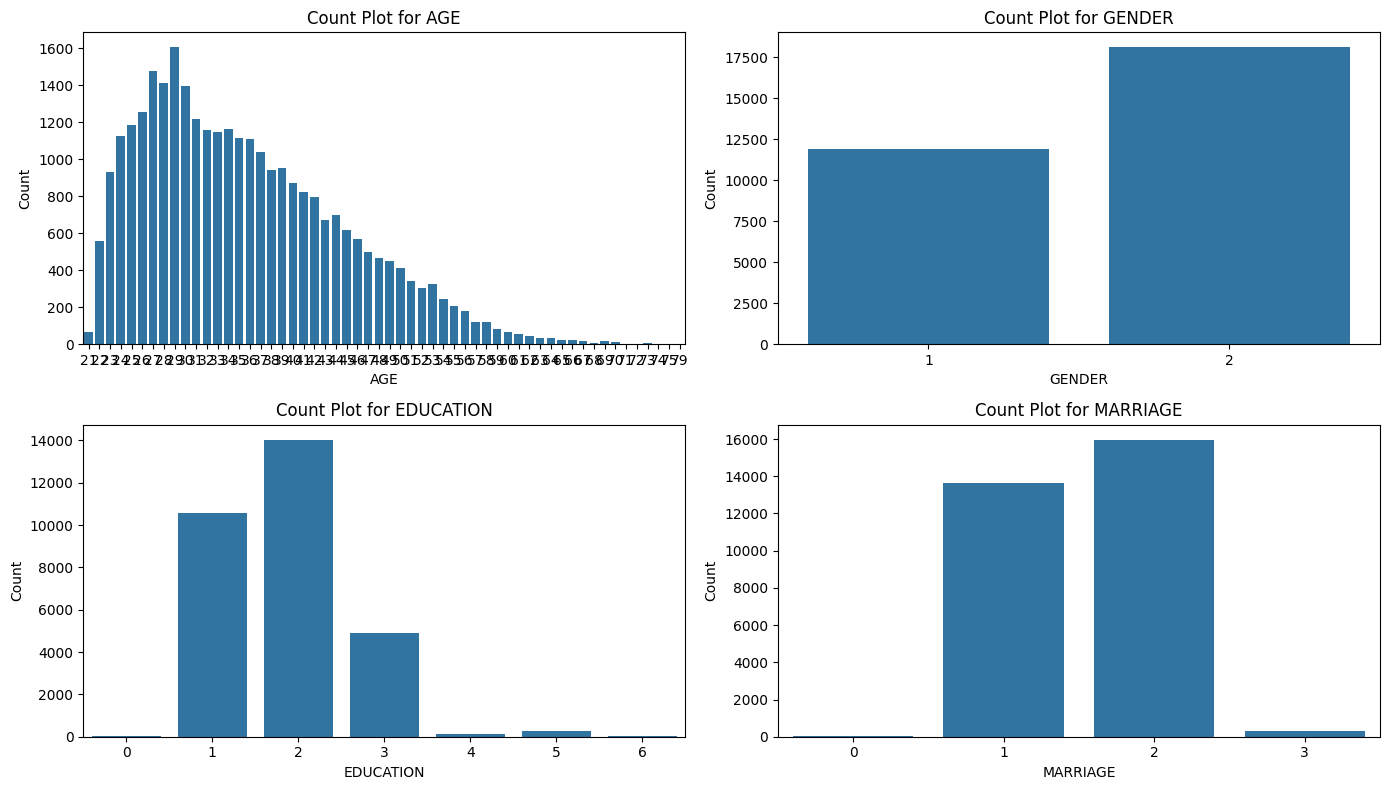

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
axes = axes.flatten()

cate_cols = ['AGE', 'GENDER', 'EDUCATION', 'MARRIAGE']

for ax, col in zip(axes, cate_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'Count Plot for {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


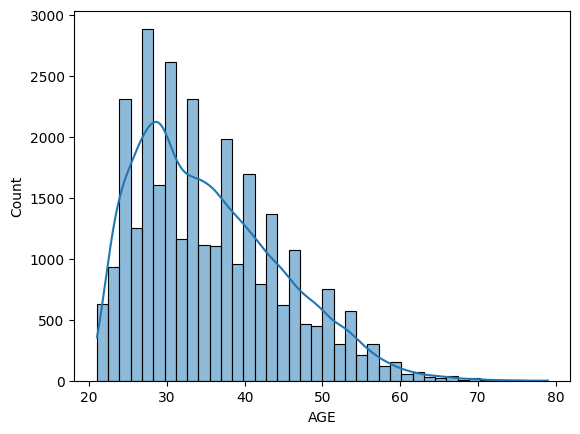

In [17]:
sns.histplot(data=df, x='AGE', bins=40, kde=True)
plt.show()

In [18]:
df.groupby(['GENDER', 'DEFAULT_NEXT_MONTH']).size().reset_index(name='Count')

,GENDER,DEFAULT_NEXT_MONTH,Count
0,1,0,9015
1,1,1,2873
2,2,0,14349
3,2,1,3763


In [19]:
df.groupby(['MARRIAGE', 'DEFAULT_NEXT_MONTH']).size().reset_index(name='Count')

,MARRIAGE,DEFAULT_NEXT_MONTH,Count
0,0,0,49
1,0,1,5
2,1,0,10453
3,1,1,3206
4,2,0,12623
5,2,1,3341
6,3,0,239
7,3,1,84


In [20]:
df.groupby(['EDUCATION', 'DEFAULT_NEXT_MONTH']).size().reset_index(name='Count')

,EDUCATION,DEFAULT_NEXT_MONTH,Count
0,0,0,14
1,1,0,8549
2,1,1,2036
3,2,0,10700
4,2,1,3330
5,3,0,3680
6,3,1,1237
7,4,0,116
8,4,1,7
9,5,0,262


Undocumented categorical values in marital status and education were mapped to the ‘Others’ category instead of being dropped, to avoid bias and information loss.

In [21]:
# Apply mapping
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Verify mapping
print(df['MARRIAGE'].value_counts())

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


/tmp/ipython-input-2829123377.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)


In [22]:
# Apply mapping
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# Verify mapping
print(df['EDUCATION'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64


/tmp/ipython-input-4163520908.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)


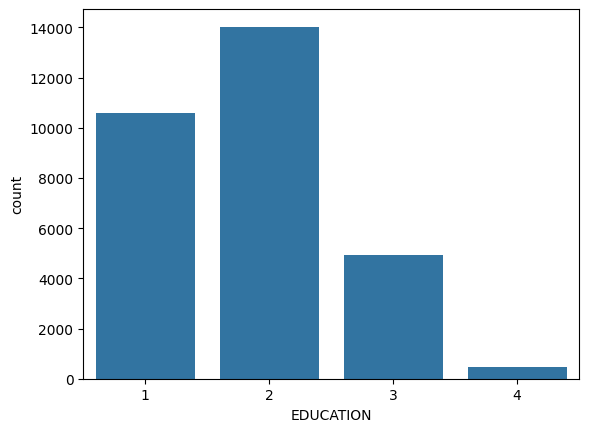

In [23]:
sns.countplot(data=df, x="EDUCATION")
plt.show()

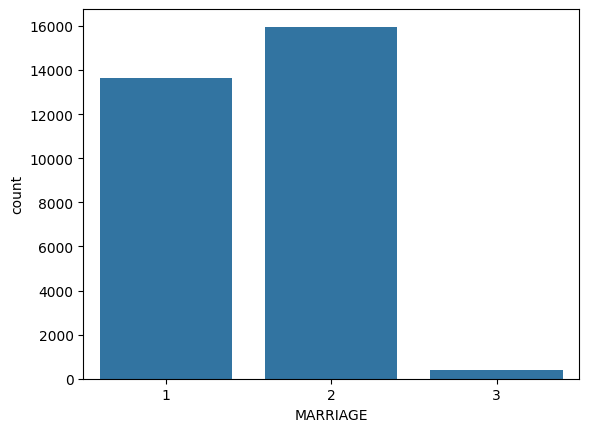

In [24]:
sns.countplot(data=df, x="MARRIAGE")
plt.show()

## Credit Exposure & Limit Analysis

### Distribution of Credit Limit

In [25]:
print(f"Minimum LIMIT_BAL: {df['LIMIT_BAL'].min()}")
print(f"Maximum LIMIT_BAL: {df['LIMIT_BAL'].max()}")

Minimum LIMIT_BAL: 10000
Maximum LIMIT_BAL: 1000000


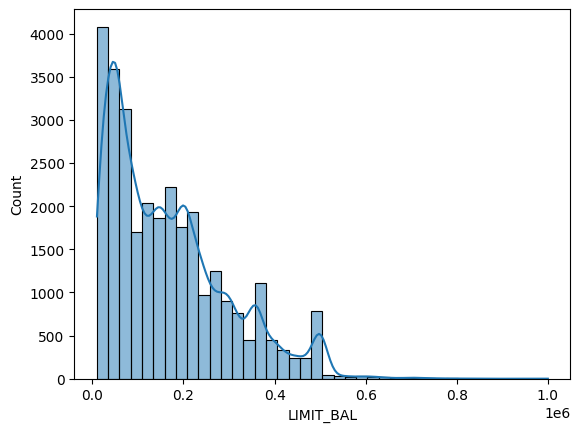

In [26]:
sns.histplot(data=df, x='LIMIT_BAL', bins=40, kde=True)
plt.show()

The credit limit distribution is strongly right-skewed, indicating that most customers belong to lower exposure segments, while a small proportion of customers hold very high credit limits. This suggests a portfolio dominated by retail/subprime to near-prime borrowers, with concentrated exposure risk in a limited number of high-limit accounts

### Default Rate by Credit Limit Buckets

/tmp/ipython-input-278414876.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('LIMIT_BUCKET')["DEFAULT_NEXT_MONTH"]


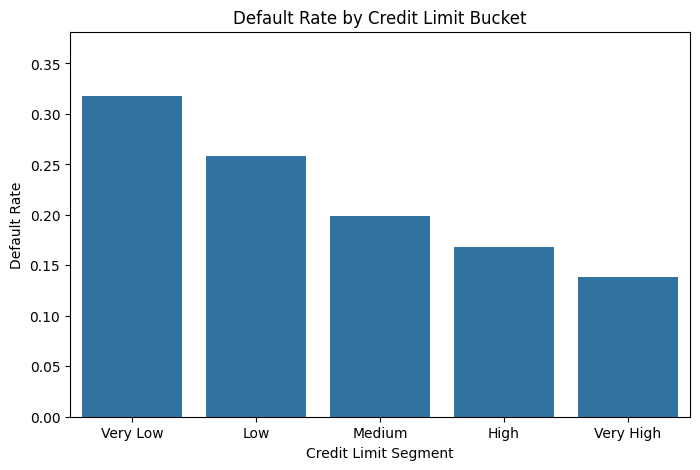

In [27]:
df['LIMIT_BUCKET'] = pd.qcut(
    df['LIMIT_BAL'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
limit_default_rate = (
    df.groupby('LIMIT_BUCKET')["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=limit_default_rate, x='LIMIT_BUCKET', y="DEFAULT_NEXT_MONTH")
plt.title('Default Rate by Credit Limit Bucket')
plt.xlabel('Credit Limit Segment')
plt.ylabel('Default Rate')
plt.ylim(0, limit_default_rate["DEFAULT_NEXT_MONTH"].max() * 1.2)
plt.show()


### LIMIT_BAL vs DEFAULT

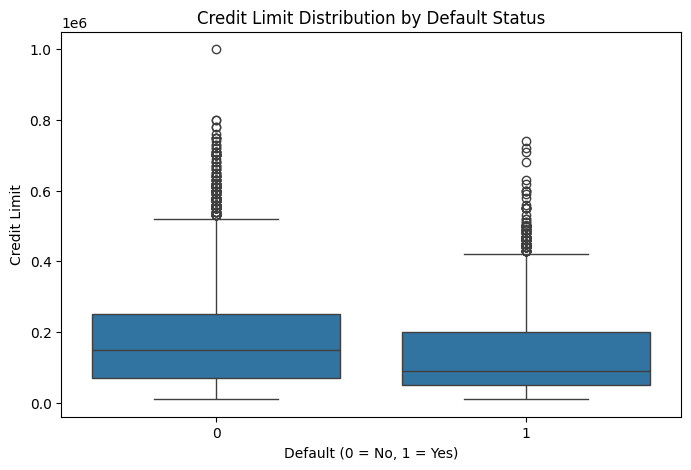

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="DEFAULT_NEXT_MONTH", y='LIMIT_BAL')
plt.title('Credit Limit Distribution by Default Status')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Credit Limit')
plt.show()


There appears to be an inverse relationship between credit limit and the likelihood of default. Clients with lower credit limits are more prone to defaulting.

## Repayment Behaviour Analysis

### Distribution of Repayment Status (Delay Severity)

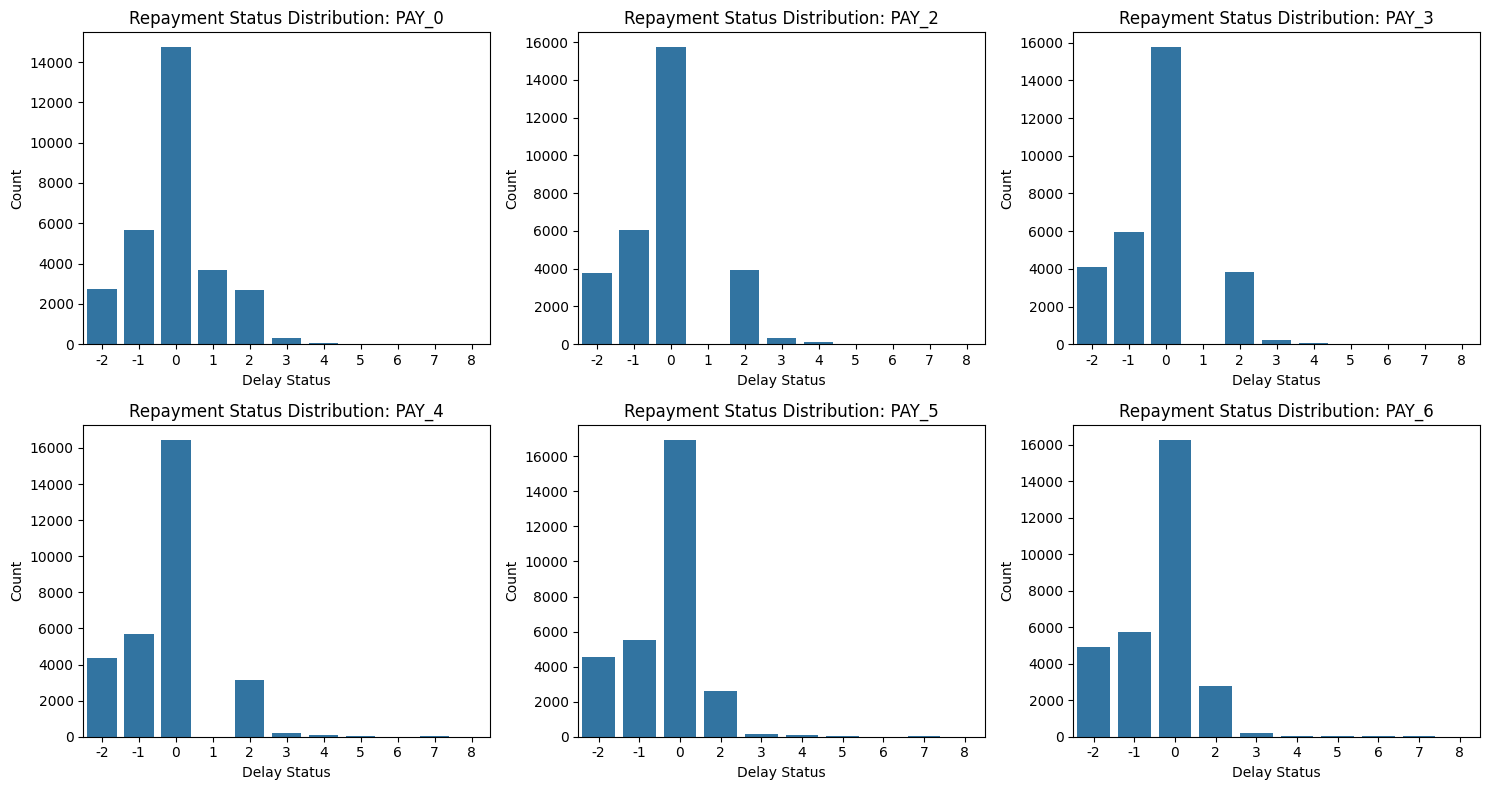

In [29]:
pay_cols=["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, pay_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'Repayment Status Distribution: {col}')
    ax.set_xlabel('Delay Status')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [30]:
df

,ID,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH,LIMIT_BUCKET
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,689,0,0,0,0,1,Very Low
1,2,120000,2,2,2,26,-1,2,0,0,...,3455,3261,0,1000,1000,1000,0,2000,1,Medium
2,3,90000,2,2,2,34,0,0,0,0,...,14948,15549,1518,1500,1000,1000,1000,5000,0,Low
3,4,50000,2,2,1,37,0,0,0,0,...,28959,29547,2000,2019,1200,1100,1069,1000,0,Very Low
4,5,50000,1,2,1,57,-1,0,-1,0,...,19146,19131,2000,36681,10000,9000,689,679,0,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,31237,15980,8500,20000,5003,3047,5000,1000,0,High
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,5190,0,1837,3526,8998,129,0,0,0,Medium
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20582,19357,0,0,22000,4200,2000,3100,1,Very Low
29998,29999,80000,1,3,1,41,1,-1,0,0,...,11855,48944,85900,3409,1178,1926,52964,1804,1,Low


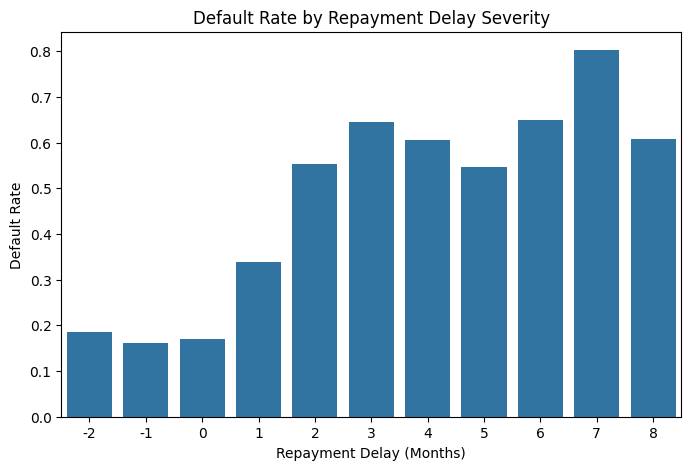

In [31]:
pay_melt = df.melt(
    id_vars='DEFAULT_NEXT_MONTH',
    value_vars=['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'],
    var_name='MONTH',
    value_name='DELAY'
)

delay_default = (
    pay_melt
    .groupby('DELAY')['DEFAULT_NEXT_MONTH']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=delay_default, x='DELAY', y='DEFAULT_NEXT_MONTH')
plt.title('Default Rate by Repayment Delay Severity')
plt.xlabel('Repayment Delay (Months)')
plt.ylabel('Default Rate')
plt.show()


### Default Rate by Repayment Delay

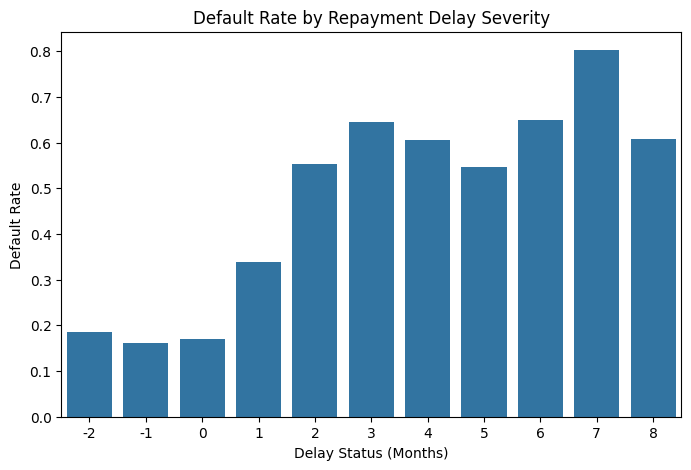

In [32]:
pay_melt = df.melt(
    id_vars="DEFAULT_NEXT_MONTH",
    value_vars=pay_cols,
    var_name='PAY_MONTH',
    value_name='DELAY'
)
delay_default_rate = (
    pay_melt
    .groupby('DELAY')["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=delay_default_rate, x='DELAY', y="DEFAULT_NEXT_MONTH")
plt.title('Default Rate by Repayment Delay Severity')
plt.xlabel('Delay Status (Months)')
plt.ylabel('Default Rate')
plt.show()


### Maximum Delay vs Default

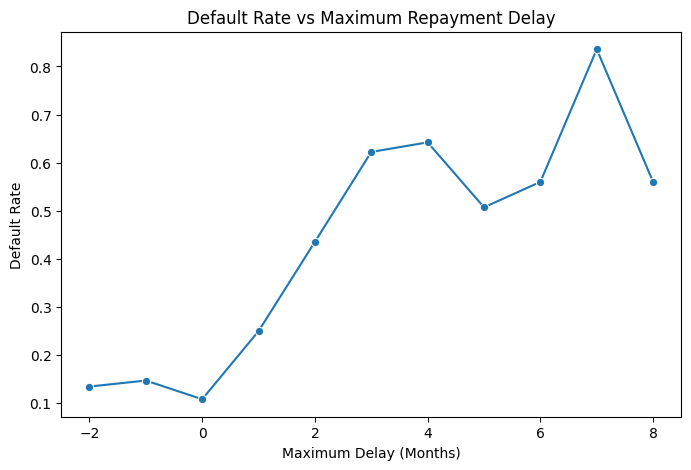

In [33]:
df['MAX_DELAY'] = df[pay_cols].max(axis=1)
max_delay_default = (
    df.groupby('MAX_DELAY')["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.lineplot(data=max_delay_default, x='MAX_DELAY', y="DEFAULT_NEXT_MONTH", marker='o')
plt.title('Default Rate vs Maximum Repayment Delay')
plt.xlabel('Maximum Delay (Months)')
plt.ylabel('Default Rate')
plt.show()


### Frequency of Delinquencies

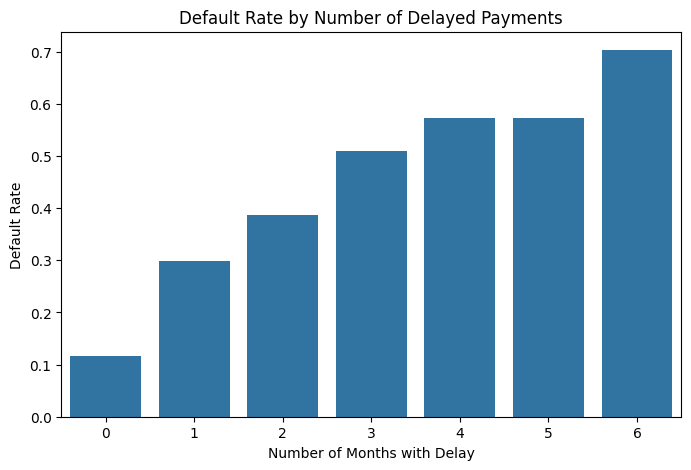

In [34]:
df['NUM_DELAYS'] = (df[pay_cols] >= 1).sum(axis=1)
delay_count_default = (
    df.groupby('NUM_DELAYS')["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=delay_count_default, x='NUM_DELAYS', y="DEFAULT_NEXT_MONTH")
plt.title('Default Rate by Number of Delayed Payments')
plt.xlabel('Number of Months with Delay')
plt.ylabel('Default Rate')
plt.show()


### Clean On-Time vs Delinquent Segmentation

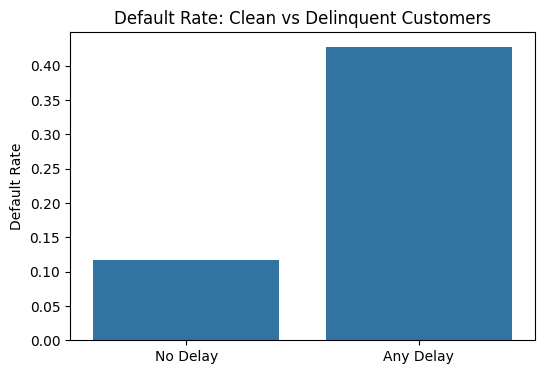

In [35]:
df['ANY_DELAY_FLAG'] = (df[pay_cols] >= 1).any(axis=1).astype(int)
df.groupby('ANY_DELAY_FLAG')["DEFAULT_NEXT_MONTH"].mean()
plt.figure(figsize=(6,4))
sns.barplot(
    x=['No Delay', 'Any Delay'],
    y=df.groupby('ANY_DELAY_FLAG')["DEFAULT_NEXT_MONTH"].mean().values
)
plt.title('Default Rate: Clean vs Delinquent Customers')
plt.ylabel('Default Rate')
plt.show()


## Billing Amount Analysis

### Distribution of Billing Amounts (Debt Exposure)

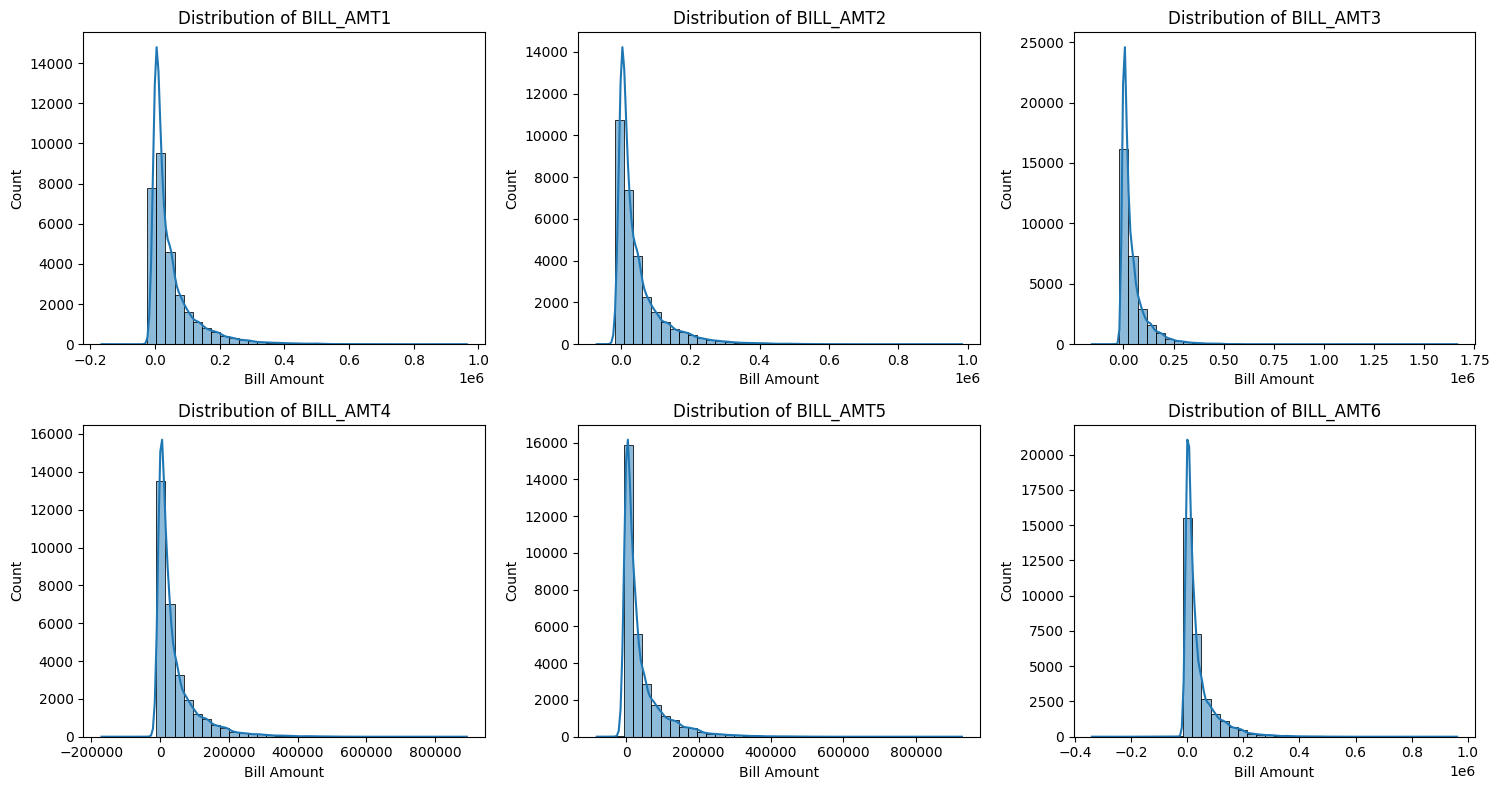

In [36]:
bill_cols = [
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6'
]
target = 'DEFAULT_NEXT_MONTH'

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, bill_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Bill Amount')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### Billing Amount vs Default

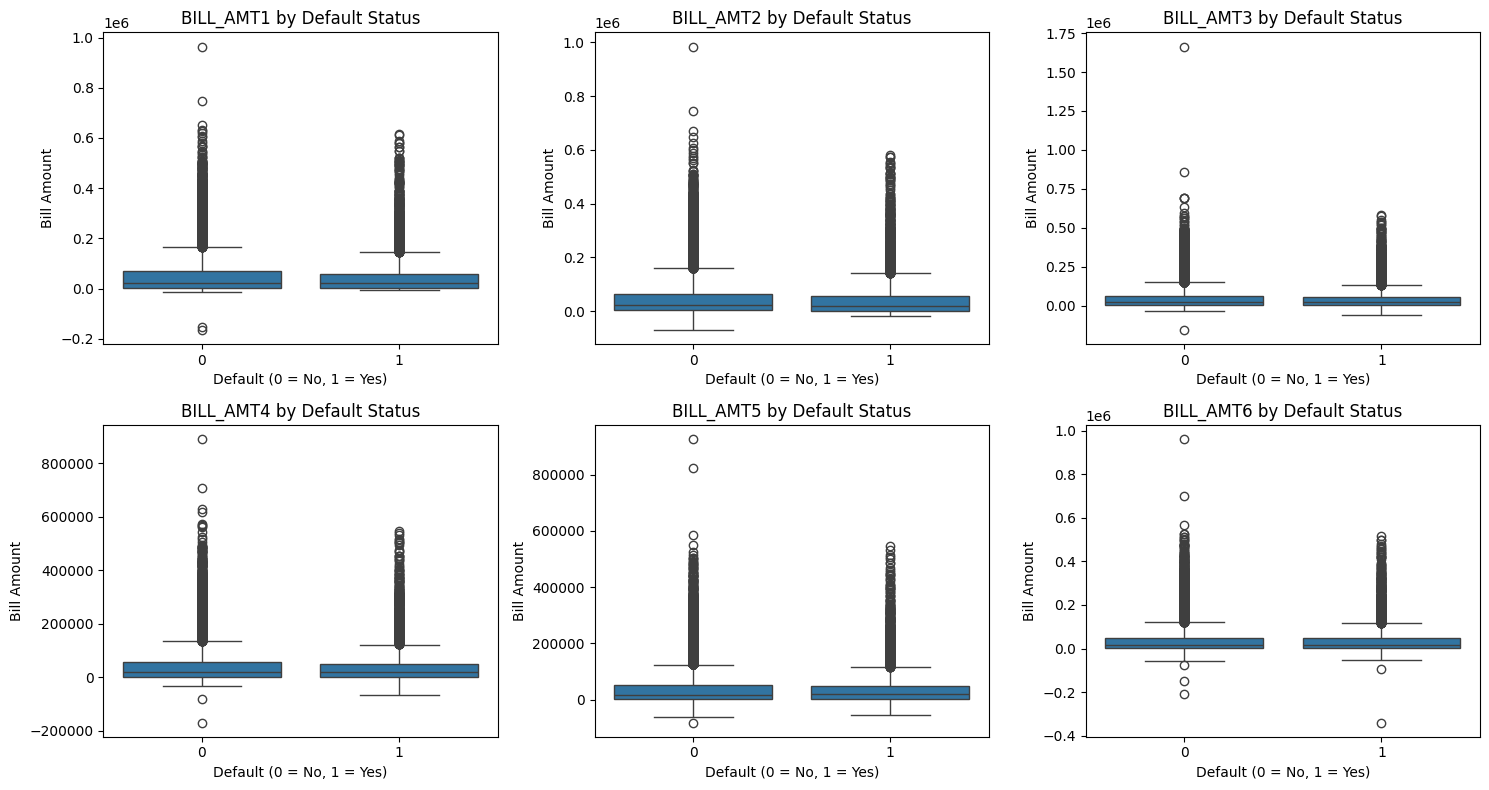

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, bill_cols):
    sns.boxplot(data=df, x=target, y=col, ax=ax)
    ax.set_title(f'{col} by Default Status')
    ax.set_xlabel('Default (0 = No, 1 = Yes)')
    ax.set_ylabel('Bill Amount')

plt.tight_layout()
plt.show()


### Average Billing Trend Over Time

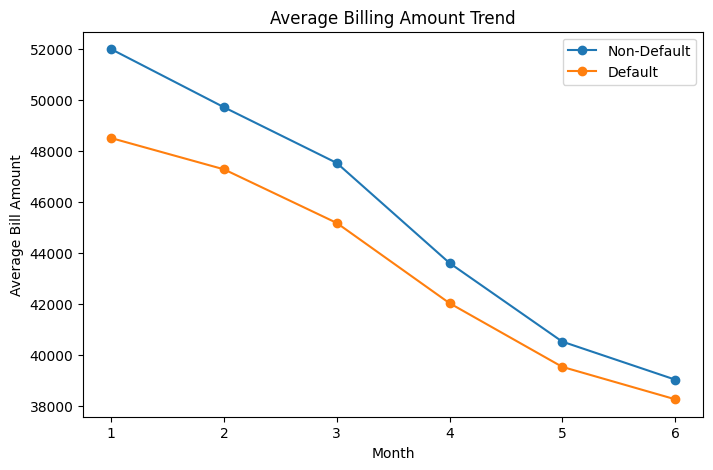

In [38]:
bill_trend = (
    df.groupby(target)[bill_cols]
    .mean()
    .T
)

bill_trend.index = range(1, 7)  # Month index
plt.figure(figsize=(8,5))
plt.plot(bill_trend.index, bill_trend[0], marker='o', label='Non-Default')
plt.plot(bill_trend.index, bill_trend[1], marker='o', label='Default')
plt.title('Average Billing Amount Trend')
plt.xlabel('Month')
plt.ylabel('Average Bill Amount')
plt.legend()
plt.show()

### Bill Growth / Deterioration Analysis

/tmp/ipython-input-4136386592.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('BILL_GROWTH_BUCKET')[target]


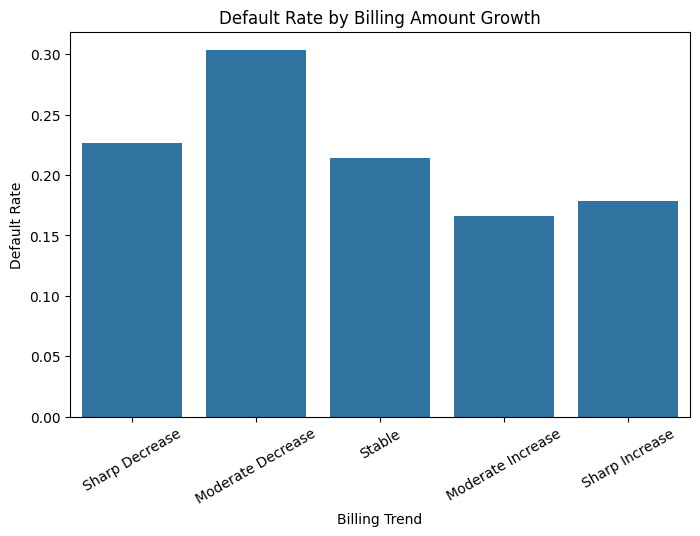

In [39]:
df['BILL_GROWTH'] = df['BILL_AMT1'] - df['BILL_AMT6']
df['BILL_GROWTH_BUCKET'] = pd.qcut(
    df['BILL_GROWTH'],
    q=5,
    labels=['Sharp Decrease','Moderate Decrease','Stable','Moderate Increase','Sharp Increase']
)

bill_growth_default = (
    df.groupby('BILL_GROWTH_BUCKET')[target]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=bill_growth_default, x='BILL_GROWTH_BUCKET', y=target)
plt.title('Default Rate by Billing Amount Growth')
plt.xlabel('Billing Trend')
plt.ylabel('Default Rate')
plt.xticks(rotation=30)
plt.show()


### High Utilization Proxy (Consistent High Bills)

/tmp/ipython-input-256359480.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AVG_BILL_BUCKET')[target]


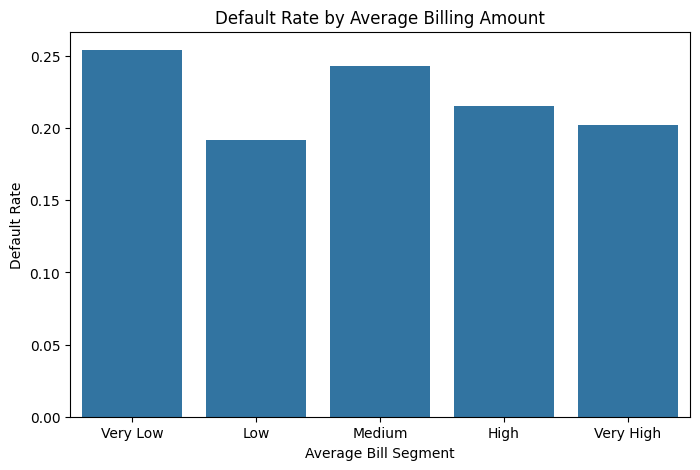

In [40]:
df['AVG_BILL_AMT'] = df[bill_cols].mean(axis=1)
df['AVG_BILL_BUCKET'] = pd.qcut(
    df['AVG_BILL_AMT'],
    q=5,
    labels=['Very Low','Low','Medium','High','Very High']
)

avg_bill_default = (
    df.groupby('AVG_BILL_BUCKET')[target]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=avg_bill_default, x='AVG_BILL_BUCKET', y=target)
plt.title('Default Rate by Average Billing Amount')
plt.xlabel('Average Bill Segment')
plt.ylabel('Default Rate')
plt.show()


### Correlation Among Billing Amounts (Redundancy Check)

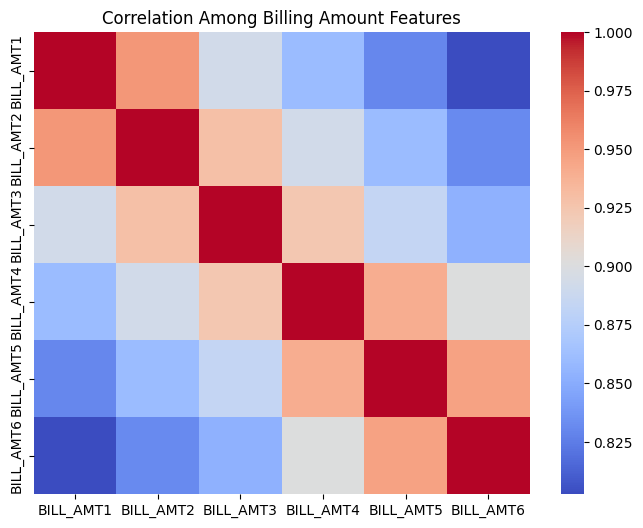

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[bill_cols].corr(),
    annot=False,
    cmap='coolwarm'
)
plt.title('Correlation Among Billing Amount Features')
plt.show()


### Payment-to-Bill Ratio (PAY_AMT / BILL_AMT) IMP - feature engineering

## Payment Amount Analysis

In [42]:
pay_amt_cols = [
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6'
]
target = 'DEFAULT_NEXT_MONTH'


### Distribution of Payment Amounts (Liquidity View)

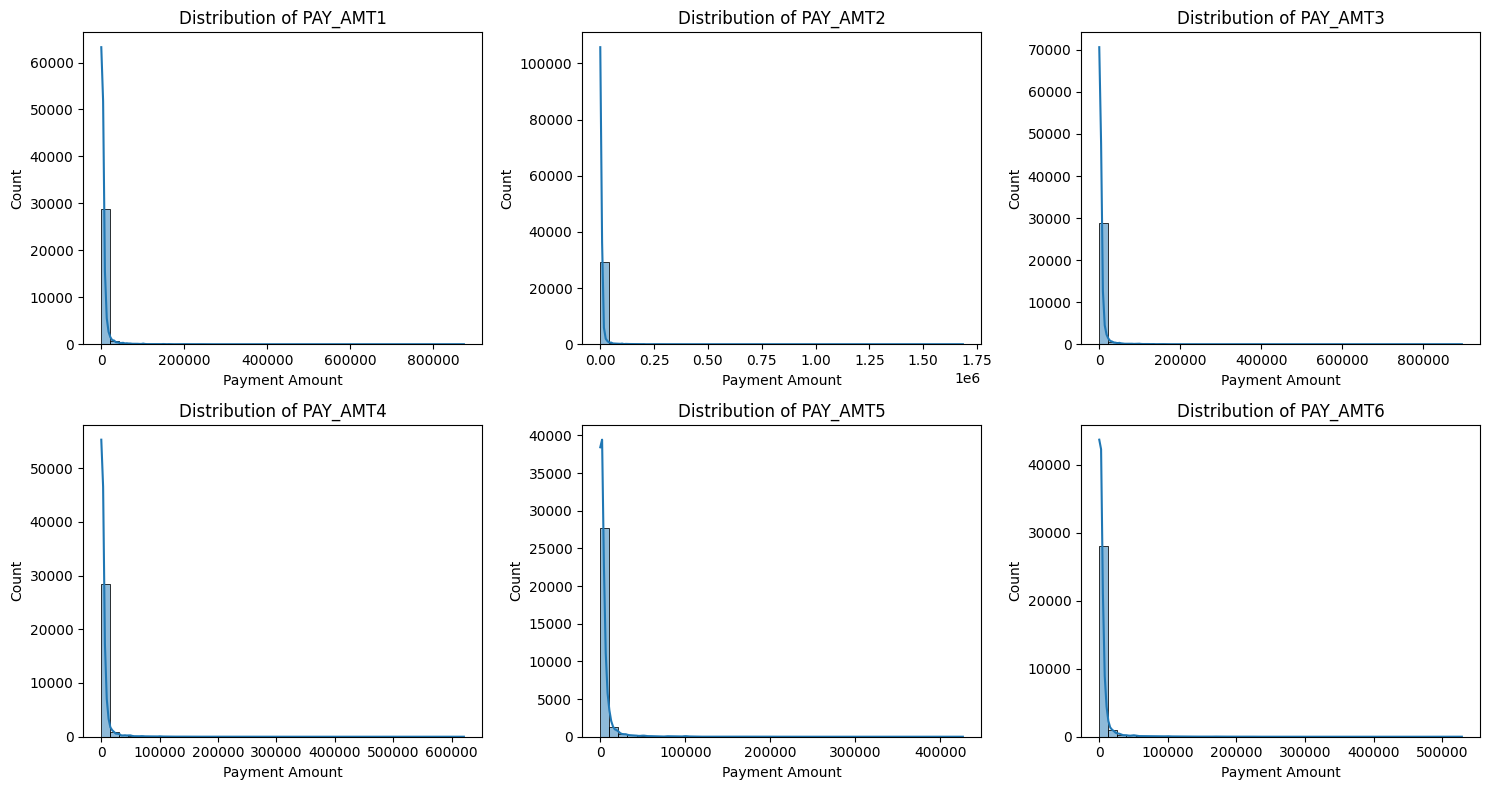

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, pay_amt_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Payment Amount')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### Payment Amount vs Default (Critical Signal)

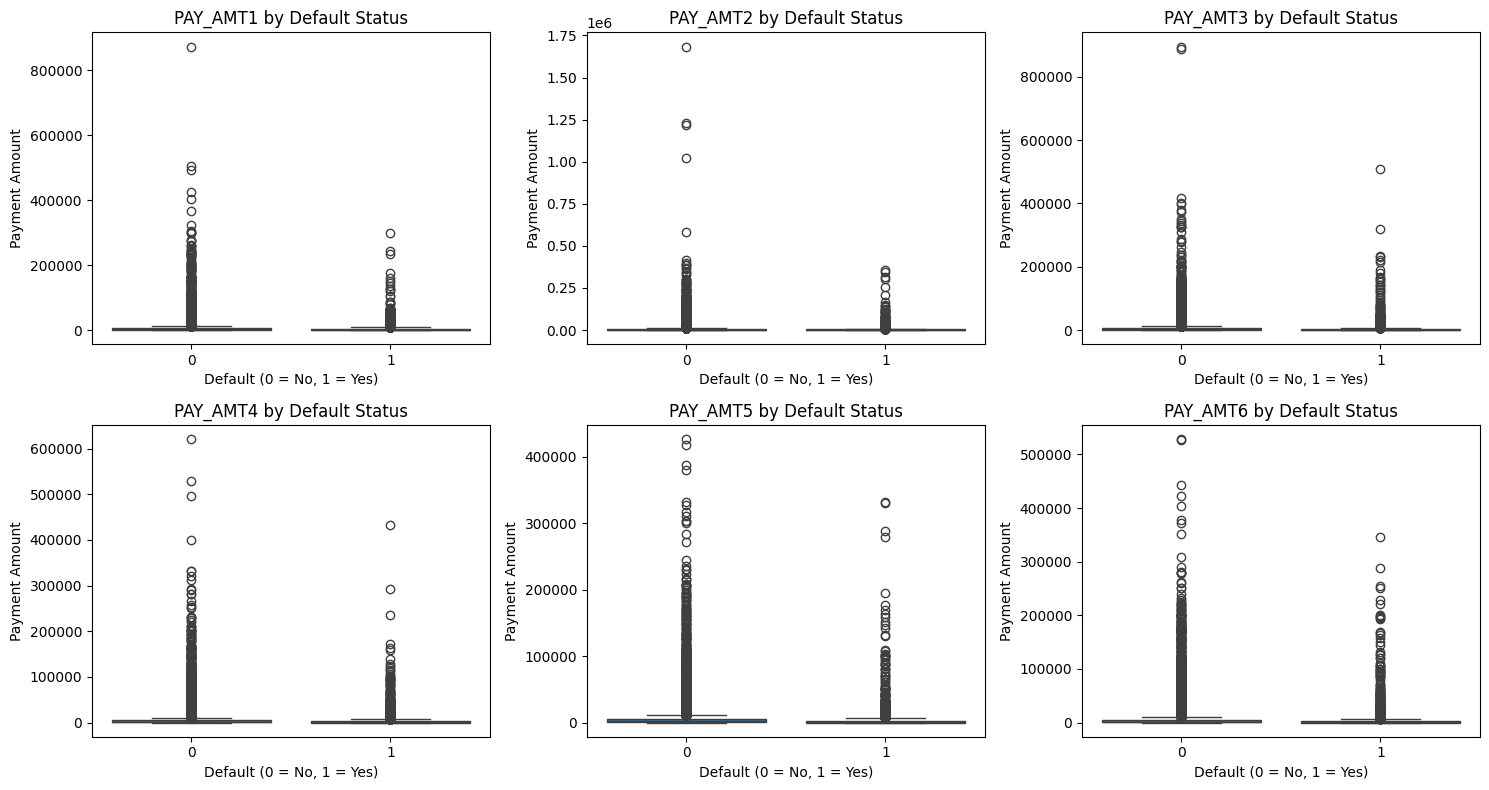

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, pay_amt_cols):
    sns.boxplot(data=df, x=target, y=col, ax=ax)
    ax.set_title(f'{col} by Default Status')
    ax.set_xlabel('Default (0 = No, 1 = Yes)')
    ax.set_ylabel('Payment Amount')

plt.tight_layout()
plt.show()


### Average Payment Trend Over Time (Behavioral Deterioration)

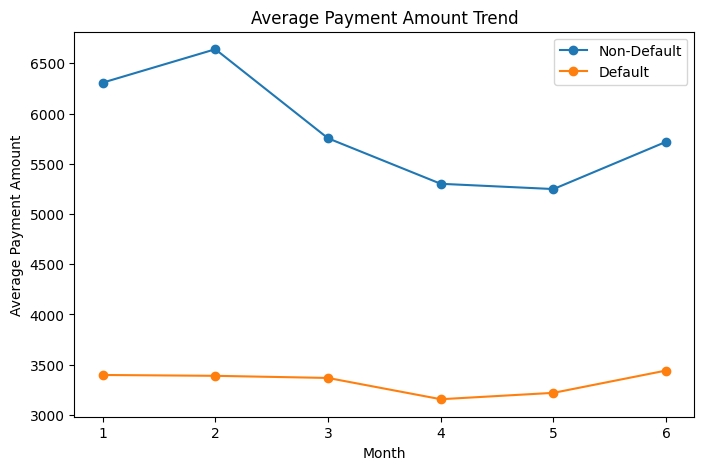

In [45]:
payment_trend = (
    df.groupby(target)[pay_amt_cols]
    .mean()
    .T
)

payment_trend.index = range(1, 7)
plt.figure(figsize=(8,5))
plt.plot(payment_trend.index, payment_trend[0], marker='o', label='Non-Default')
plt.plot(payment_trend.index, payment_trend[1], marker='o', label='Default')
plt.title('Average Payment Amount Trend')
plt.xlabel('Month')
plt.ylabel('Average Payment Amount')
plt.legend()
plt.show()


### Zero / Minimal Payment Analysis (Early Warning)

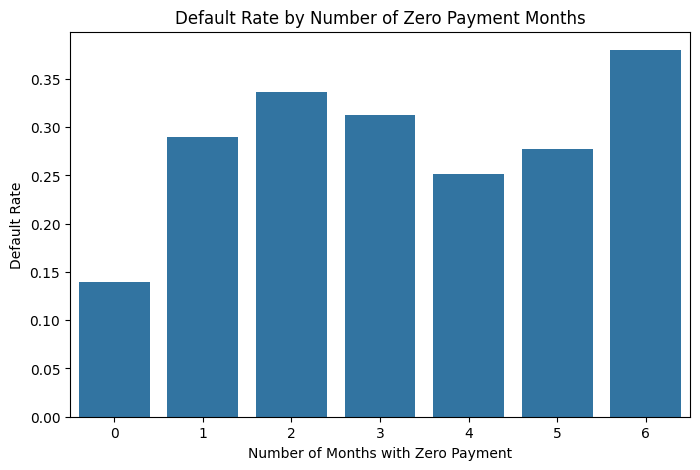

In [46]:
for col in pay_amt_cols:
    df[col + '_ZERO_FLAG'] = (df[col] == 0).astype(int)
zero_cols = [col + '_ZERO_FLAG' for col in pay_amt_cols]
df['NUM_ZERO_PAYMENTS'] = df[zero_cols].sum(axis=1)
zero_payment_default = (
    df.groupby('NUM_ZERO_PAYMENTS')[target]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=zero_payment_default, x='NUM_ZERO_PAYMENTS', y=target)
plt.title('Default Rate by Number of Zero Payment Months')
plt.xlabel('Number of Months with Zero Payment')
plt.ylabel('Default Rate')
plt.show()


### Payment Stability (Consistency Measure)

/tmp/ipython-input-2878006103.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PAYMENT_STD_BUCKET')[target]


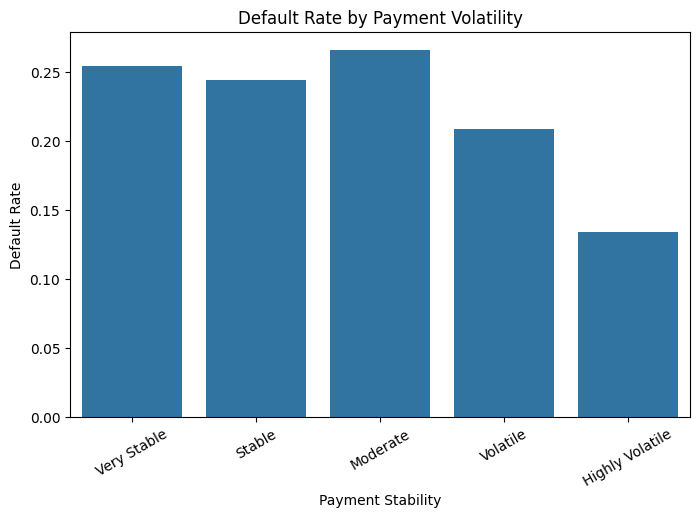

In [47]:
df['PAYMENT_STD'] = df[pay_amt_cols].std(axis=1)
df['PAYMENT_STD_BUCKET'] = pd.qcut(
    df['PAYMENT_STD'],
    q=5,
    labels=['Very Stable','Stable','Moderate','Volatile','Highly Volatile']
)
payment_std_default = (
    df.groupby('PAYMENT_STD_BUCKET')[target]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=payment_std_default, x='PAYMENT_STD_BUCKET', y=target)
plt.title('Default Rate by Payment Volatility')
plt.xlabel('Payment Stability')
plt.ylabel('Default Rate')
plt.xticks(rotation=30)
plt.show()


### Correlation Among Payment Amounts (Redundancy)

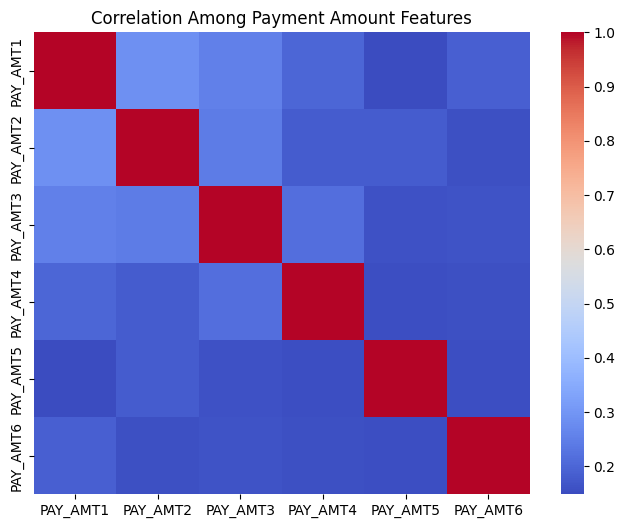

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[pay_amt_cols].corr(),
    cmap='coolwarm',
    annot=False
)
plt.title('Correlation Among Payment Amount Features')
plt.show()


## Payment-to-Bill Ratio Analysis (PAY_AMT / BILL_AMT)

In [49]:
bill_cols = [
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6'
]

pay_amt_cols = [
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

target = 'DEFAULT_NEXT_MONTH'


In [50]:
import numpy as np

for i in range(1, 7):
    df[f'PAY_BILL_RATIO_{i}'] = np.where(
        df[f'BILL_AMT{i}'] > 0,
        df[f'PAY_AMT{i}'] / df[f'BILL_AMT{i}'],
        0
    )


### Distribution of Payment-to-Bill Ratio

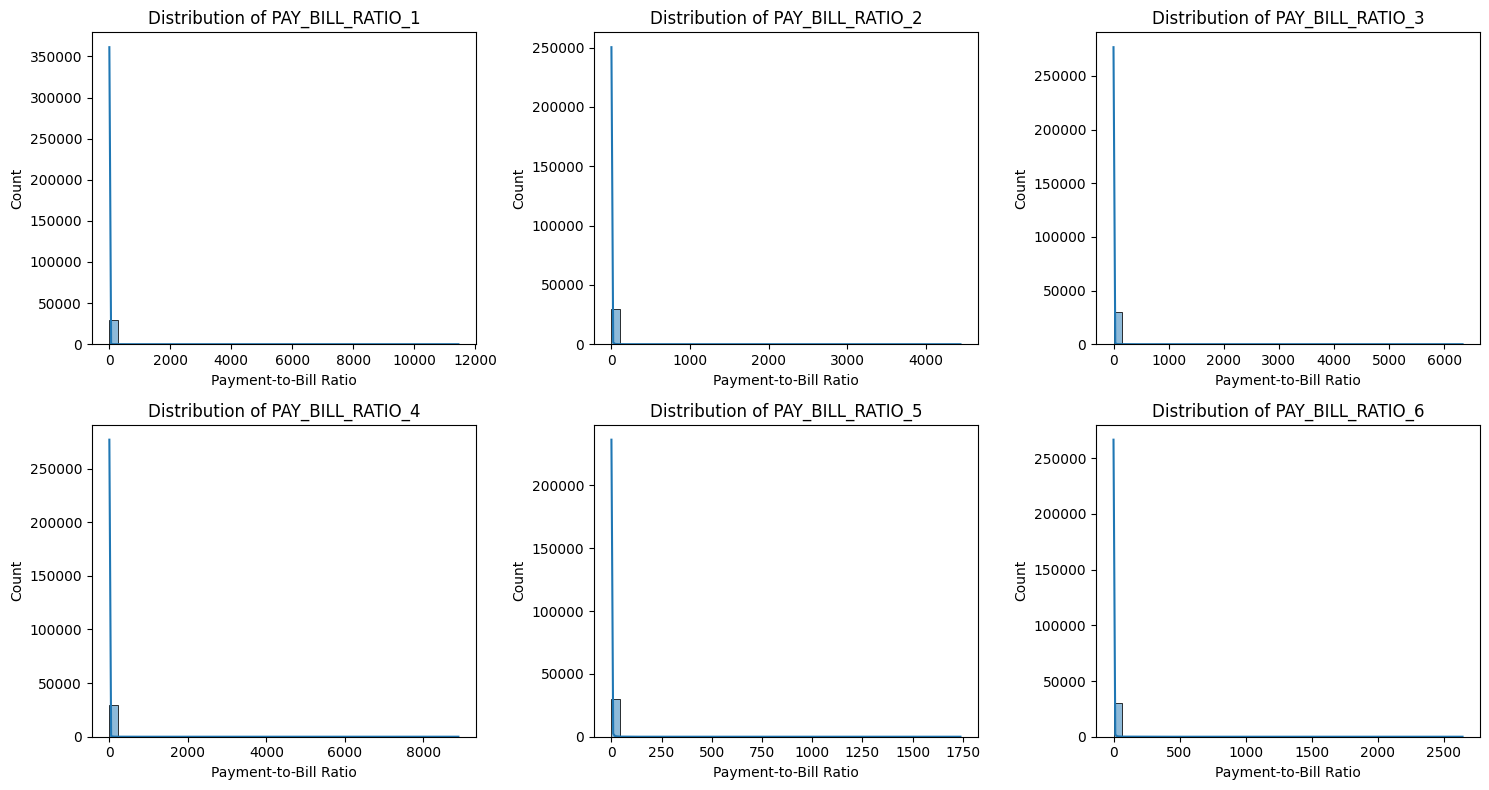

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [f'PAY_BILL_RATIO_{i}' for i in range(1, 7)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, ratio_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Payment-to-Bill Ratio')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### Payment-to-Bill Ratio vs Default

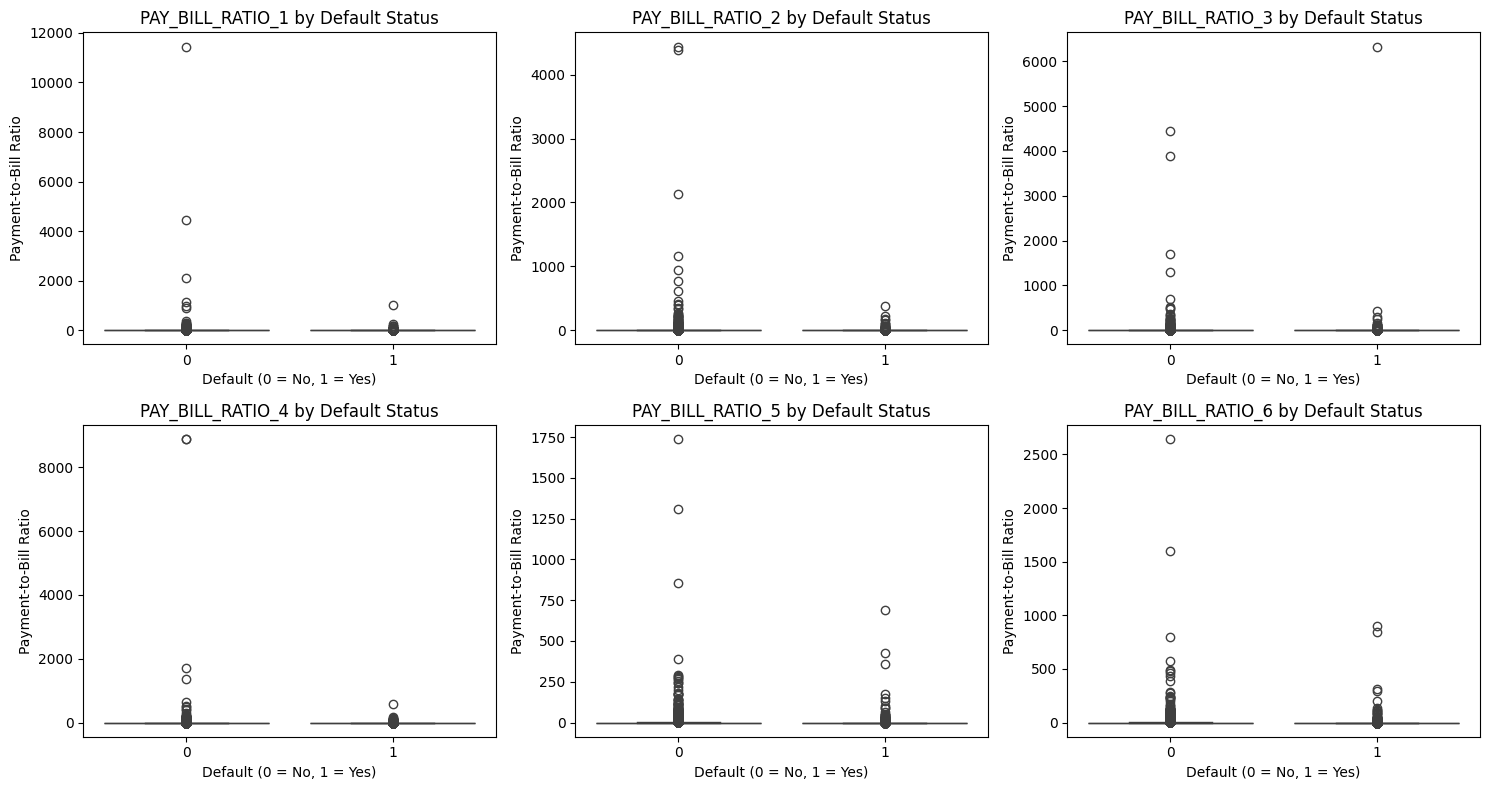

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, ratio_cols):
    sns.boxplot(data=df, x=target, y=col, ax=ax)
    ax.set_title(f'{col} by Default Status')
    ax.set_xlabel('Default (0 = No, 1 = Yes)')
    ax.set_ylabel('Payment-to-Bill Ratio')

plt.tight_layout()
plt.show()


### Average Ratio Trend Over Time (Behavioral Deterioration)

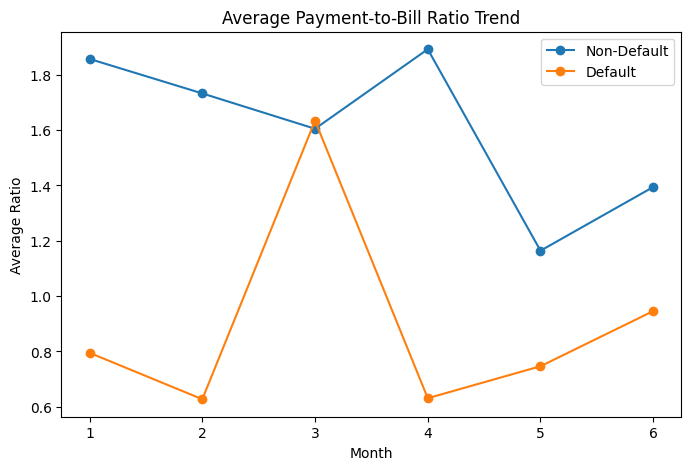

In [53]:
ratio_trend = (
    df.groupby(target)[ratio_cols]
    .mean()
    .T
)

ratio_trend.index = range(1, 7)
plt.figure(figsize=(8,5))
plt.plot(ratio_trend.index, ratio_trend[0], marker='o', label='Non-Default')
plt.plot(ratio_trend.index, ratio_trend[1], marker='o', label='Default')
plt.title('Average Payment-to-Bill Ratio Trend')
plt.xlabel('Month')
plt.ylabel('Average Ratio')
plt.legend()
plt.show()


## Temporal Behaviour Analysis — Risk Over Time

### Month-wise Comparison — Repayment Status (PAY*)

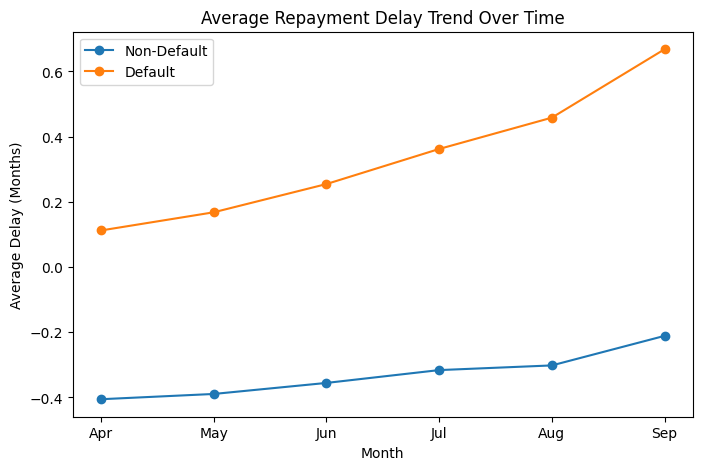

In [54]:
pay_cols = ['PAY_6','PAY_5','PAY_4','PAY_3','PAY_2','PAY_0']  # Old → Recent
target = 'DEFAULT_NEXT_MONTH'

pay_trend = (
    df.groupby(target)[pay_cols]
    .mean()
    .T
)

pay_trend.index = ['Apr','May','Jun','Jul','Aug','Sep']

plt.figure(figsize=(8,5))
plt.plot(pay_trend.index, pay_trend[0], marker='o', label='Non-Default')
plt.plot(pay_trend.index, pay_trend[1], marker='o', label='Default')
plt.title('Average Repayment Delay Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Average Delay (Months)')
plt.legend()
plt.show()


### Month-wise Comparison — Billing Amount (BILL_AMT*)

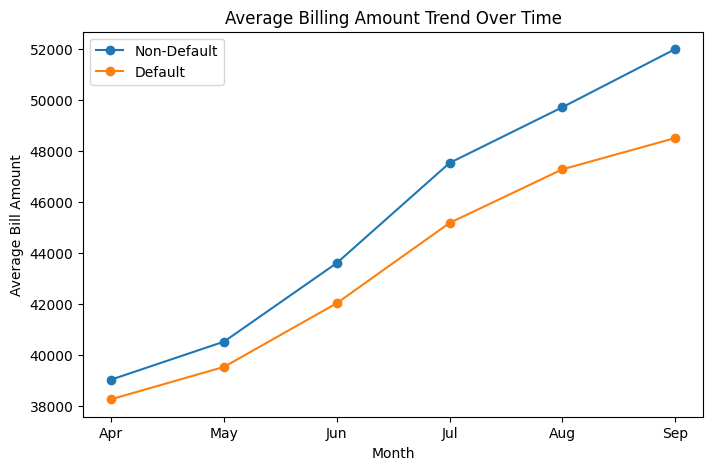

In [55]:
bill_cols = ['BILL_AMT6','BILL_AMT5','BILL_AMT4','BILL_AMT3','BILL_AMT2','BILL_AMT1']

bill_trend = (
    df.groupby(target)[bill_cols]
    .mean()
    .T
)

bill_trend.index = ['Apr','May','Jun','Jul','Aug','Sep']
plt.figure(figsize=(8,5))
plt.plot(bill_trend.index, bill_trend[0], marker='o', label='Non-Default')
plt.plot(bill_trend.index, bill_trend[1], marker='o', label='Default')
plt.title('Average Billing Amount Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Average Bill Amount')
plt.legend()
plt.show()


### Recent vs Older Behavior Impact

In [56]:
df['RECENT_DELAY'] = df['PAY_0']
df['PAST_DELAY_AVG'] = df[['PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)
recent_vs_past = (
    df[['RECENT_DELAY','PAST_DELAY_AVG', target]]
    .groupby(target)
    .mean()
)

recent_vs_past


,RECENT_DELAY,PAST_DELAY_AVG
DEFAULT_NEXT_MONTH,,
0,-0.211222,-0.353784
1,0.668174,0.270976


## Correlation Analysis

### Full Correlation Heatmap

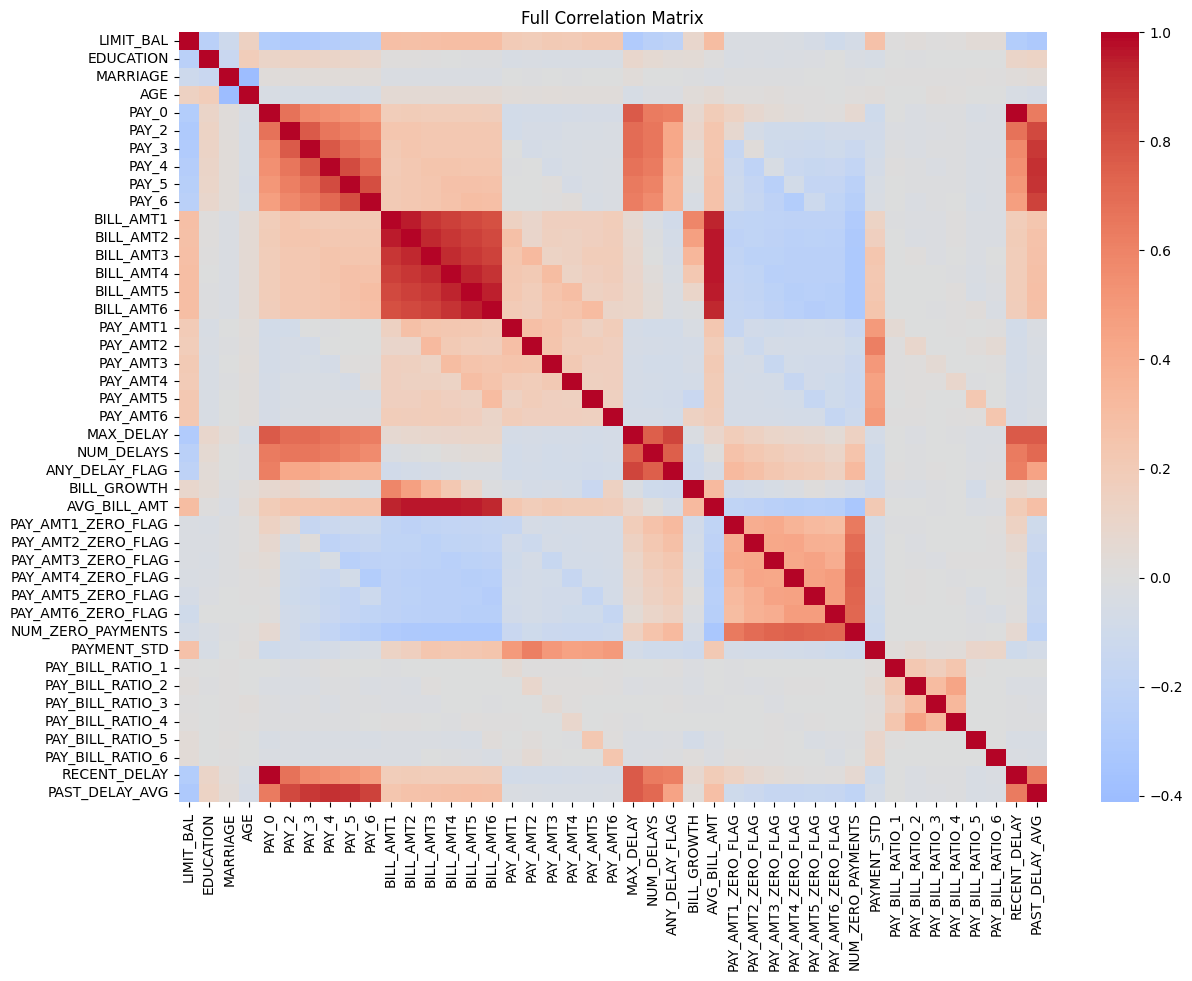

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop ID if still present
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Full Correlation Matrix")
plt.show()

### Correlation — Bill Amounts

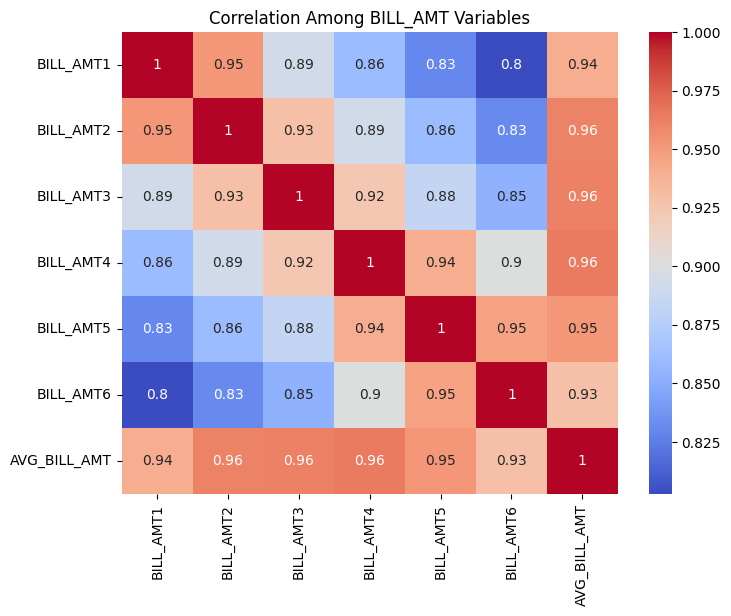

In [58]:
bill_cols = [col for col in df.columns if 'BILL_AMT' in col]

bill_corr = df[bill_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(bill_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Among BILL_AMT Variables")
plt.show()

### Correlation — Payment Amounts

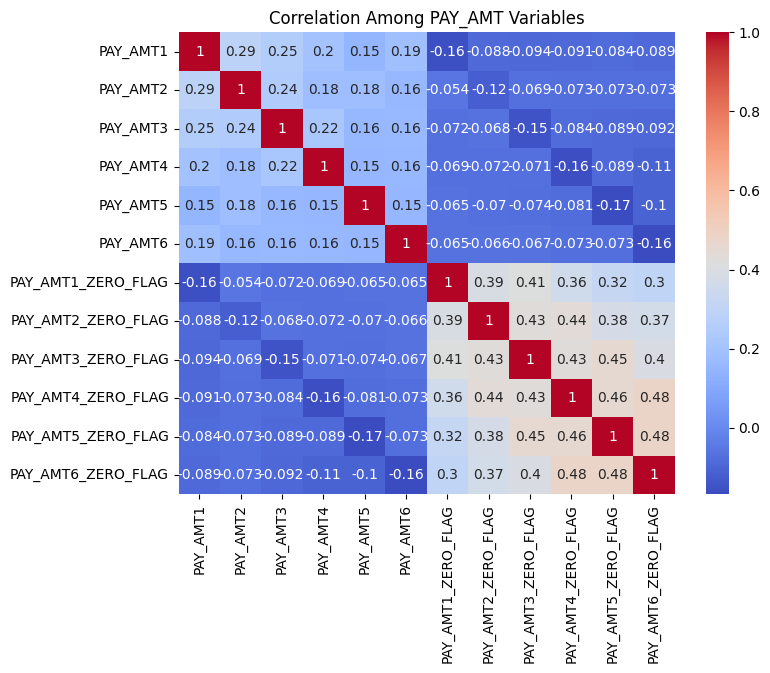

In [59]:
pay_amt_cols = [col for col in df.columns if 'PAY_AMT' in col]

pay_amt_corr = df[pay_amt_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(pay_amt_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Among PAY_AMT Variables")
plt.show()

### Correlation — Repayment Delays

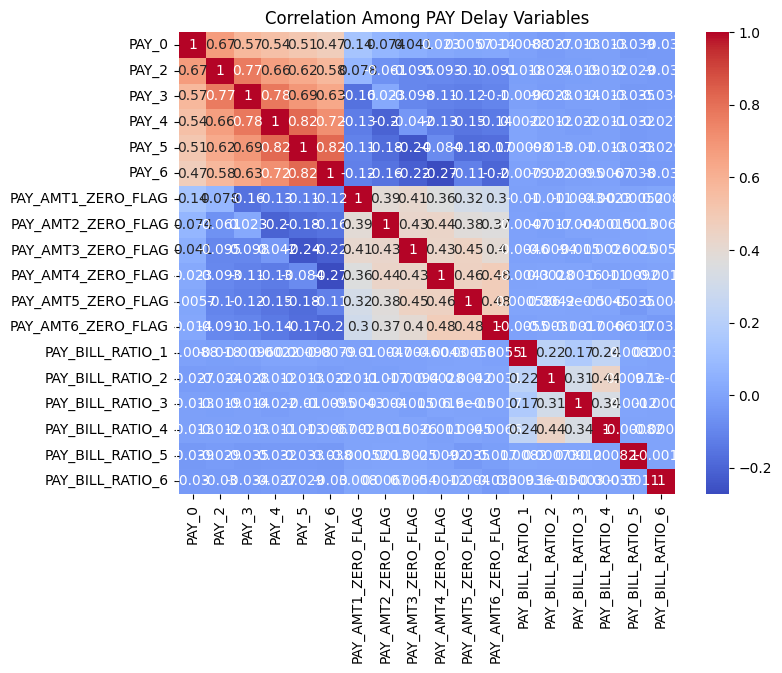

In [60]:
pay_delay_cols = [col for col in df.columns if col.startswith('PAY_') and col != 'PAY_AMT1' and col != 'PAY_AMT2' and col != 'PAY_AMT3' and col != 'PAY_AMT4' and col != 'PAY_AMT5' and col != 'PAY_AMT6']

pay_delay_corr = df[pay_delay_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(pay_delay_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Among PAY Delay Variables")
plt.show()

In [61]:
df.columns

Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'DEFAULT_NEXT_MONTH', 'LIMIT_BUCKET', 'MAX_DELAY', 'NUM_DELAYS',
       'ANY_DELAY_FLAG', 'BILL_GROWTH', 'BILL_GROWTH_BUCKET', 'AVG_BILL_AMT',
       'AVG_BILL_BUCKET', 'PAY_AMT1_ZERO_FLAG', 'PAY_AMT2_ZERO_FLAG',
       'PAY_AMT3_ZERO_FLAG', 'PAY_AMT4_ZERO_FLAG', 'PAY_AMT5_ZERO_FLAG',
       'PAY_AMT6_ZERO_FLAG', 'NUM_ZERO_PAYMENTS', 'PAYMENT_STD',
       'PAYMENT_STD_BUCKET', 'PAY_BILL_RATIO_1', 'PAY_BILL_RATIO_2',
       'PAY_BILL_RATIO_3', 'PAY_BILL_RATIO_4', 'PAY_BILL_RATIO_5',
       'PAY_BILL_RATIO_6', 'RECENT_DELAY', 'PAST_DELAY_AVG'],
      dtype='object')

# FEATURE ENGINEERING

In [62]:
df_fe=df

In [63]:
df_fe.head()

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAYMENT_STD,PAYMENT_STD_BUCKET,PAY_BILL_RATIO_1,PAY_BILL_RATIO_2,PAY_BILL_RATIO_3,PAY_BILL_RATIO_4,PAY_BILL_RATIO_5,PAY_BILL_RATIO_6,RECENT_DELAY,PAST_DELAY_AVG
0,20000,2,2,1,24,2,2,-1,-1,-2,...,281.283072,Very Stable,0.000000,0.222115,0.000000,0.000000,0.000000,0.000000,2,-0.8
1,120000,2,2,2,26,-1,2,0,0,0,...,752.772653,Stable,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,-1,0.8
2,90000,2,2,2,34,0,0,0,0,0,...,1569.815488,Moderate,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,0,0.0
3,50000,2,2,1,37,0,0,0,0,0,...,478.058155,Very Stable,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,0,0.0
4,50000,1,2,1,57,-1,0,-1,0,0,...,13786.230736,Highly Volatile,0.232099,6.469312,0.279057,0.429799,0.035987,0.035492,-1,-0.2
